# Chapter 1 ASIC Hard-Case Review

This notebook is a thin review layer over the saved ASIC Chapter 1 hard-case artifacts. It does **not** rerun hard-case classification logic. It prefers exported cluster hard-case artifacts when they are available locally and falls back to synthetic local review artifacts otherwise.

Embedded outputs, if present, reflect the last time the notebook was executed and may predate the current artifact-source resolution rules.


## 1. Load And Sanity Check Data
        

In [3]:
from __future__ import annotations

import os
import sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd

if "MPLCONFIGDIR" not in os.environ:
    mplconfigdir = Path("/tmp") / "chapter1_mortality_decomposition_matplotlib"
    mplconfigdir.mkdir(parents=True, exist_ok=True)
    os.environ["MPLCONFIGDIR"] = str(mplconfigdir)

try:
    from IPython import get_ipython
    from IPython.display import Image, Markdown, display
    ipython_shell = get_ipython()
    if ipython_shell is None:
        raise RuntimeError("Plain Python execution: use fallback display helpers.")
    try:
        ipython_shell.run_line_magic("matplotlib", "inline")
    except Exception:
        pass
except Exception:
    ipython_shell = None

    class Markdown(str):
        pass

    def display(obj: object) -> None:
        print(obj)

import matplotlib
if ipython_shell is None:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt


def finalize_figure(fig=None) -> None:
    fig = fig or plt.gcf()
    backend = matplotlib.get_backend().lower()
    if "agg" in backend:
        if ipython_shell is not None:
            buffer = BytesIO()
            fig.savefig(buffer, format="png", bbox_inches="tight")
            buffer.seek(0)
            display(Image(data=buffer.getvalue()))
            buffer.close()
        plt.close(fig)
        return
    plt.show()


def looks_like_repo_root(path: Path) -> bool:
    return (path / "pyproject.toml").exists() and (path / "src" / "chapter1_mortality_decomposition").exists()


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if looks_like_repo_root(candidate):
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from chapter1_mortality_decomposition.hard_case_definition import DEFAULT_HARD_CASE_OUTPUT_DIR
from chapter1_mortality_decomposition.notebook_artifact_sources import (
    build_artifact_source_markdown,
    chapter1_result_relative_path,
    resolve_notebook_artifact_source,
)

try:
    from chapter1_mortality_decomposition.hard_case_agreement import DEFAULT_AGREEMENT_OUTPUT_DIR
except Exception:
    DEFAULT_AGREEMENT_OUTPUT_DIR = None

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

PRIMARY_HORIZON = 24
SECONDARY_HORIZON = 48

LOGISTIC_HARD_CASE_SOURCE = resolve_notebook_artifact_source(
    chapter1_result_relative_path(DEFAULT_HARD_CASE_OUTPUT_DIR),
    label="Logistic hard-case package",
    repo_root=REPO_ROOT,
)
LOGISTIC_HARD_CASE_ROOT = LOGISTIC_HARD_CASE_SOURCE.path
LOGISTIC_STAY_LEVEL_PATH = LOGISTIC_HARD_CASE_ROOT / "stay_level_hard_case_flags.csv"
LOGISTIC_SUMMARY_PATH = LOGISTIC_HARD_CASE_ROOT / "horizon_hard_case_summary.csv"

if DEFAULT_AGREEMENT_OUTPUT_DIR is not None:
    try:
        AGREEMENT_SOURCE = resolve_notebook_artifact_source(
            chapter1_result_relative_path(DEFAULT_AGREEMENT_OUTPUT_DIR),
            label="Hard-case agreement package",
            repo_root=REPO_ROOT,
        )
        AGREEMENT_ROOT = AGREEMENT_SOURCE.path
    except FileNotFoundError:
        AGREEMENT_SOURCE = None
        AGREEMENT_ROOT = None
else:
    AGREEMENT_SOURCE = None
    AGREEMENT_ROOT = None

AGREEMENT_STAY_LEVEL_PATH = (
    AGREEMENT_ROOT / "fatal_stay_level_hard_case_agreement.csv"
    if AGREEMENT_ROOT is not None
    else None
)
AGREEMENT_SUMMARY_PATH = (
    AGREEMENT_ROOT / "horizon_hard_case_agreement_summary.csv"
    if AGREEMENT_ROOT is not None
    else None
)

source_rows = [LOGISTIC_HARD_CASE_SOURCE]
if AGREEMENT_SOURCE is not None:
    source_rows.append(AGREEMENT_SOURCE)
display(Markdown(build_artifact_source_markdown(source_rows, display_root=REPO_ROOT)))
if AGREEMENT_SOURCE is None:
    display(Markdown("**Hard-case agreement package:** not found under `cluster-results` or `artifacts/chapter1`; agreement overlays will be skipped."))


def relative_path(path: Path | None) -> str:
    if path is None:
        return "<not configured>"
    try:
        return str(path.resolve().relative_to(REPO_ROOT))
    except Exception:
        return str(path)


def read_csv_required(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required hard-case artifact is missing: {path}")
    return pd.read_csv(path)


def read_csv_optional(path: Path | None) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)


logistic_stay = read_csv_required(LOGISTIC_STAY_LEVEL_PATH)
logistic_summary = read_csv_required(LOGISTIC_SUMMARY_PATH)
agreement_stay = read_csv_optional(AGREEMENT_STAY_LEVEL_PATH)
agreement_summary = read_csv_optional(AGREEMENT_SUMMARY_PATH)
agreement_available = not agreement_stay.empty and not agreement_summary.empty


def extract_model_labels(frame: pd.DataFrame) -> str:
    labels: list[str] = []
    for column in frame.columns:
        if column == "model_name":
            labels.extend(frame[column].dropna().astype("string").unique().tolist())
        elif column.endswith("_model_name"):
            labels.extend(frame[column].dropna().astype("string").unique().tolist())
    ordered: list[str] = []
    seen: set[str] = set()
    for label in labels:
        if label not in seen:
            ordered.append(label)
            seen.add(label)
    return ", ".join(ordered) if ordered else "n/a"


artifact_paths = pd.DataFrame(
    [
        {
            "artifact_name": "logistic stay-level hard cases",
            "path": relative_path(LOGISTIC_STAY_LEVEL_PATH),
            "required": True,
            "exists": LOGISTIC_STAY_LEVEL_PATH.exists(),
        },
        {
            "artifact_name": "logistic horizon summary",
            "path": relative_path(LOGISTIC_SUMMARY_PATH),
            "required": True,
            "exists": LOGISTIC_SUMMARY_PATH.exists(),
        },
        {
            "artifact_name": "agreement stay-level artifact",
            "path": relative_path(AGREEMENT_STAY_LEVEL_PATH),
            "required": False,
            "exists": bool(AGREEMENT_STAY_LEVEL_PATH is not None and AGREEMENT_STAY_LEVEL_PATH.exists()),
        },
        {
            "artifact_name": "agreement horizon summary",
            "path": relative_path(AGREEMENT_SUMMARY_PATH),
            "required": False,
            "exists": bool(AGREEMENT_SUMMARY_PATH is not None and AGREEMENT_SUMMARY_PATH.exists()),
        },
    ]
)

def describe_frame(name: str, frame: pd.DataFrame) -> dict[str, object]:
    return {
        "artifact_name": name,
        "row_count": int(frame.shape[0]),
        "available_horizons": ", ".join(str(h) for h in sorted(pd.to_numeric(frame["horizon_h"], errors="coerce").dropna().astype(int).unique().tolist())) if "horizon_h" in frame.columns else "n/a",
        "hospital_count": int(frame["hospital_id"].nunique(dropna=True)) if "hospital_id" in frame.columns else pd.NA,
        "available_models": extract_model_labels(frame),
    }


artifact_overview = pd.DataFrame(
    [
        describe_frame("logistic stay-level hard cases", logistic_stay),
        describe_frame("logistic horizon summary", logistic_summary),
        describe_frame("agreement stay-level artifact", agreement_stay) if agreement_available else describe_frame("agreement stay-level artifact", pd.DataFrame()),
        describe_frame("agreement horizon summary", agreement_summary) if agreement_available else describe_frame("agreement horizon summary", pd.DataFrame()),
    ]
)

primary_sanity = pd.DataFrame(
    [
        {"metric": "repo_root", "value": str(REPO_ROOT)},
        {"metric": "logistic stay-level rows", "value": int(logistic_stay.shape[0])},
        {"metric": "available horizons", "value": ", ".join(str(h) for h in sorted(logistic_stay["horizon_h"].dropna().astype(int).unique().tolist()))},
        {"metric": "available hospitals", "value": ", ".join(sorted(logistic_stay["hospital_id"].dropna().astype("string").unique().tolist()))},
        {"metric": "fatal last-point rows", "value": int(logistic_stay["label_value"].eq(1).sum())},
        {"metric": "hard-case rows", "value": int(logistic_stay["hard_case_flag"].astype(bool).sum())},
        {"metric": "agreement artifacts available", "value": bool(agreement_available)},
    ]
)

primary_qc_columns = [
    "stay_id_global",
    "hospital_id",
    "horizon_h",
    "label_value",
    "instance_id",
    "block_index",
    "prediction_time_h",
    "predicted_probability",
    "nonfatal_q75_threshold",
    "hard_case_flag",
]

display(Markdown("### Artifact Paths"))
display(artifact_paths)

display(Markdown("### Artifact Overview"))
display(artifact_overview)

display(Markdown("### Primary Hard-Case Sanity Summary"))
display(primary_sanity)

display(Markdown("### Primary Stay-Level QC Preview"))
display(logistic_stay[primary_qc_columns].head(12))

display(Markdown("### Primary Horizon Summary"))
display(logistic_summary)

if agreement_available:
    agreement_qc_columns = [
        "stay_id_global",
        "hospital_id",
        "horizon_h",
        "logistic_predicted_probability",
        "logistic_hard_case_flag",
        "xgb_recal_predicted_probability",
        "xgb_recal_hard_case_flag",
        "hard_case_agreement_flag",
        "hard_case_logistic_only_flag",
        "hard_case_xgb_only_flag",
    ]
    display(Markdown("### Agreement Artifact QC Preview"))
    display(agreement_stay[agreement_qc_columns].head(12))
else:
    display(Markdown("_Agreement artifacts are not available at the configured default path, so the cross-model section below will be skipped._"))
        

## Artifact Source Mode

All notebook inputs currently resolve to `cluster export` artifacts. These are the authoritative local mirror of approved HPC outputs.

| input | tier | path |
| --- | --- | --- |
| Logistic hard-case package | `cluster export` | `cluster-results/chapter1_true_results/evaluation/asic/hard_cases/primary_medians/logistic_regression` |
| Hard-case agreement package | `cluster export` | `cluster-results/chapter1_true_results/evaluation/asic/hard_cases/primary_medians/agreement/logistic_regression_vs_xgboost_platt` |

### Artifact Paths

,artifact_name,path,required,exists
0,logistic stay-level hard cases,cluster-results/chapter1_true_results/evaluati...,True,True
1,logistic horizon summary,cluster-results/chapter1_true_results/evaluati...,True,True
2,agreement stay-level artifact,cluster-results/chapter1_true_results/evaluati...,False,False
3,agreement horizon summary,cluster-results/chapter1_true_results/evaluati...,False,True


### Artifact Overview

,artifact_name,row_count,available_horizons,hospital_count,available_models
0,logistic stay-level hard cases,31382,"8, 16, 24, 48, 72",4,logistic_regression
1,logistic horizon summary,5,"8, 16, 24, 48, 72",<NA>,logistic_regression
2,agreement stay-level artifact,0,n/a,<NA>,n/a
3,agreement horizon summary,0,n/a,<NA>,n/a


...

### Primary Stay-Level QC Preview

,stay_id_global,hospital_id,horizon_h,label_value,instance_id,block_index,prediction_time_h,predicted_probability,nonfatal_q75_threshold,hard_case_flag
0,asic_UK02_100,asic_UK02,8,0,asic_UK02_100__b12__h8,12,104,0.001135,0.004425,False
1,asic_UK02_102,asic_UK02,8,0,asic_UK02_102__b20__h8,20,168,0.002333,0.004425,False
2,asic_UK02_103,asic_UK02,8,0,asic_UK02_103__b61__h8,61,496,0.003980,0.004425,False
3,asic_UK02_104,asic_UK02,8,0,asic_UK02_104__b42__h8,42,344,0.003735,0.004425,False
4,asic_UK02_105,asic_UK02,8,1,asic_UK02_105__b18__h8,18,152,0.002258,0.004425,True
5,asic_UK02_106,asic_UK02,8,1,asic_UK02_106__b25__h8,25,208,0.008353,0.004425,False
6,asic_UK02_108,asic_UK02,8,0,asic_UK02_108__b15__h8,15,128,0.000126,0.004425,False
7,asic_UK02_11,asic_UK02,8,0,asic_UK02_11__b23__h8,23,192,0.001758,0.004425,False
8,asic_UK02_110,asic_UK02,8,0,asic_UK02_110__b18__h8,18,152,0.002585,0.004425,False
9,asic_UK02_111,asic_UK02,8,0,asic_UK02_111__b87__h8,87,704,0.004510,0.004425,False


### Primary Horizon Summary

,horizon_h,model_name,n_prediction_rows_loaded,n_rows_collapsed_before_last_point,n_selected_last_points,n_nonfatal_last_points,n_fatal_last_points,nonfatal_q75_threshold,n_hard_cases,pct_fatal_hard_cases,subgroup_size_warning,warning_reason
0,8,logistic_regression,236204,229852,6352,4713,1639,0.004425,351,0.214155,False,NaN
1,16,logistic_regression,233965,227582,6383,4713,1670,0.009295,342,0.204790,False,NaN
2,24,logistic_regression,231596,225218,6378,4696,1682,0.014598,346,0.205707,False,NaN
3,48,logistic_regression,224195,217956,6239,4542,1697,0.032415,352,0.207425,False,NaN
4,72,logistic_regression,216573,210543,6030,4326,1704,0.052678,364,0.213615,False,NaN


_Agreement artifacts are not available at the configured default path, so the cross-model section below will be skipped._

In [4]:
def plot_annotated_heatmap(
    table: pd.DataFrame,
    *,
    ax: plt.Axes,
    title: str,
    cmap: str = "Blues",
    value_format: str = "{:.0f}",
    colorbar_label: str | None = None,
    vmin: float | None = None,
    vmax: float | None = None,
) -> None:
    if table.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
        ax.set_title(title)
        return

    values = table.to_numpy(dtype=float)
    if np.isfinite(values).any():
        if vmin is None:
            vmin = float(np.nanmin(values))
        if vmax is None:
            vmax = float(np.nanmax(values))
    image = ax.imshow(values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(table.shape[1]))
    ax.set_xticklabels([str(column) for column in table.columns])
    ax.set_yticks(range(table.shape[0]))
    ax.set_yticklabels([str(index) for index in table.index])
    ax.set_xlabel("Horizon (h)")
    ax.set_ylabel("Hospital")
    ax.set_title(title)

    for row_idx in range(table.shape[0]):
        for col_idx in range(table.shape[1]):
            value = values[row_idx, col_idx]
            if np.isnan(value):
                label = ""
            else:
                label = value_format.format(value)
            ax.text(col_idx, row_idx, label, ha="center", va="center", color="black", fontsize=9)

    colorbar = plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    if colorbar_label is not None:
        colorbar.set_label(colorbar_label)


def plot_last_point_risk_distribution(
    stay_level: pd.DataFrame,
    *,
    horizon_h: int,
    ax: plt.Axes,
) -> None:
    subset = stay_level[stay_level["horizon_h"].astype(int).eq(int(horizon_h))].copy()
    if subset.empty:
        ax.axis("off")
        ax.text(0.5, 0.5, f"No rows for {horizon_h}h", ha="center", va="center")
        ax.set_title(f"{horizon_h}h")
        return

    threshold = float(subset["nonfatal_q75_threshold"].dropna().iloc[0])
    nonfatal = subset.loc[subset["label_value"].eq(0), "predicted_probability"].astype(float)
    fatal_nonhard = subset.loc[
        subset["label_value"].eq(1) & ~subset["hard_case_flag"].astype(bool),
        "predicted_probability",
    ].astype(float)
    fatal_hard = subset.loc[subset["hard_case_flag"].astype(bool), "predicted_probability"].astype(float)

    combined = pd.concat([nonfatal, fatal_nonhard, fatal_hard], ignore_index=True)
    positive = combined[np.isfinite(combined) & combined.gt(0)]
    if positive.empty:
        lower = 1e-6
        upper = 1.0
    else:
        lower = max(float(positive.min()), 1e-6)
        upper = max(float(positive.max()) * 1.15, threshold * 1.15, lower * 10)
    bins = np.geomspace(lower, upper, 28)

    def clipped(series: pd.Series) -> np.ndarray:
        values = pd.to_numeric(series, errors="coerce").to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        return np.clip(values, lower, None)

    ax.hist(clipped(nonfatal), bins=bins, alpha=0.65, color="#4c78a8", label=f"Nonfatal (n={len(nonfatal)})")
    ax.hist(clipped(fatal_nonhard), bins=bins, alpha=0.60, color="#f58518", label=f"Fatal non-hard (n={len(fatal_nonhard)})")
    if len(fatal_hard) > 0:
        ax.hist(clipped(fatal_hard), bins=bins, alpha=0.85, color="#e45756", label=f"Fatal hard case (n={len(fatal_hard)})")
    ax.axvline(max(threshold, lower), color="black", linestyle="--", linewidth=1.6, label=f"Nonfatal q75 = {threshold:.4f}")
    ax.set_xscale("log")
    ax.set_xlabel("Last-point predicted probability (log scale)")
    ax.set_ylabel("Stay count")
    ax.set_title(f"{int(horizon_h)}h last-point risk distribution")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=9)


def agreement_category(frame: pd.DataFrame) -> pd.Series:
    category = pd.Series("neither", index=frame.index, dtype="string")
    category = category.mask(frame["hard_case_agreement_flag"].astype(bool), "both")
    category = category.mask(frame["hard_case_logistic_only_flag"].astype(bool), "logistic_only")
    category = category.mask(frame["hard_case_xgb_only_flag"].astype(bool), "xgb_only")
    return category
        

## 2. Hard-Case Subgroup Size And Rates
        

### Compact Summary Table

,horizon_h,nonfatal_q75_threshold,n_fatal_last_points,n_hard_cases,pct_fatal_hard_cases,subgroup_size_warning,warning_reason
0,8,0.004425,1639,351,0.214155,False,NaN
1,16,0.009295,1670,342,0.204790,False,NaN
2,24,0.014598,1682,346,0.205707,False,NaN
3,48,0.032415,1697,352,0.207425,False,NaN
4,72,0.052678,1704,364,0.213615,False,NaN


### Threshold Table

,horizon_h,nonfatal_q75_threshold
0,8,0.004425
1,16,0.009295
2,24,0.014598
3,48,0.032415
4,72,0.052678


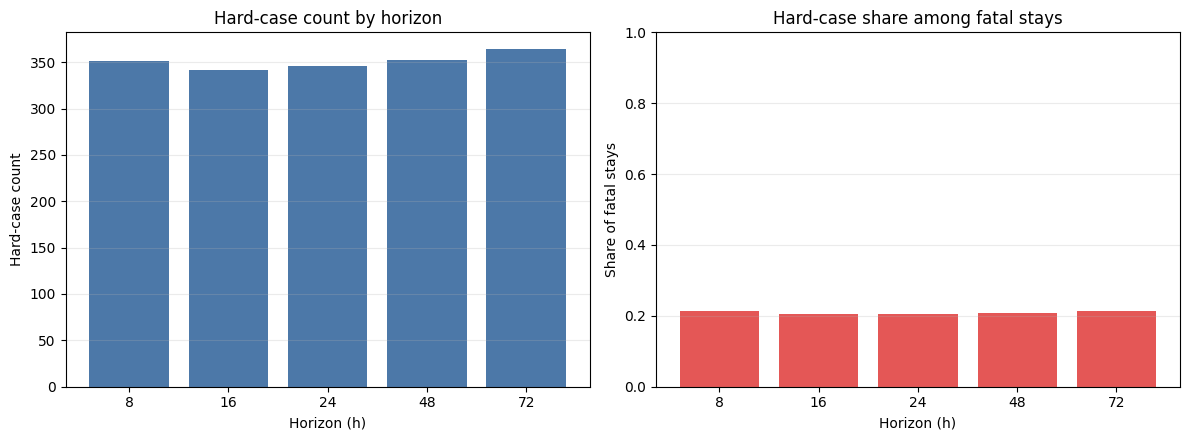

In [5]:
hard_case_overview = logistic_summary[
    [
        "horizon_h",
        "nonfatal_q75_threshold",
        "n_fatal_last_points",
        "n_hard_cases",
        "pct_fatal_hard_cases",
        "subgroup_size_warning",
        "warning_reason",
    ]
].sort_values("horizon_h").reset_index(drop=True)

display(Markdown("### Compact Summary Table"))
display(hard_case_overview)

display(Markdown("### Threshold Table"))
display(logistic_summary[["horizon_h", "nonfatal_q75_threshold"]].sort_values("horizon_h").reset_index(drop=True))

plot_frame = logistic_summary.sort_values("horizon_h").reset_index(drop=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
axes[0].bar(plot_frame["horizon_h"].astype(str), plot_frame["n_hard_cases"], color="#4c78a8")
axes[0].set_title("Hard-case count by horizon")
axes[0].set_xlabel("Horizon (h)")
axes[0].set_ylabel("Hard-case count")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(plot_frame["horizon_h"].astype(str), plot_frame["pct_fatal_hard_cases"], color="#e45756")
axes[1].set_title("Hard-case share among fatal stays")
axes[1].set_xlabel("Horizon (h)")
axes[1].set_ylabel("Share of fatal stays")
axes[1].set_ylim(0.0, 1.0)
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
finalize_figure(fig)
        

## 3. Threshold Context / Risk-Distribution Visualization

These plots use the saved stay-level last-point artifact only. They show the nonfatal distribution, the fatal non-hard distribution, the hard-case fatal distribution, and the horizon-specific nonfatal `q75` threshold.
        

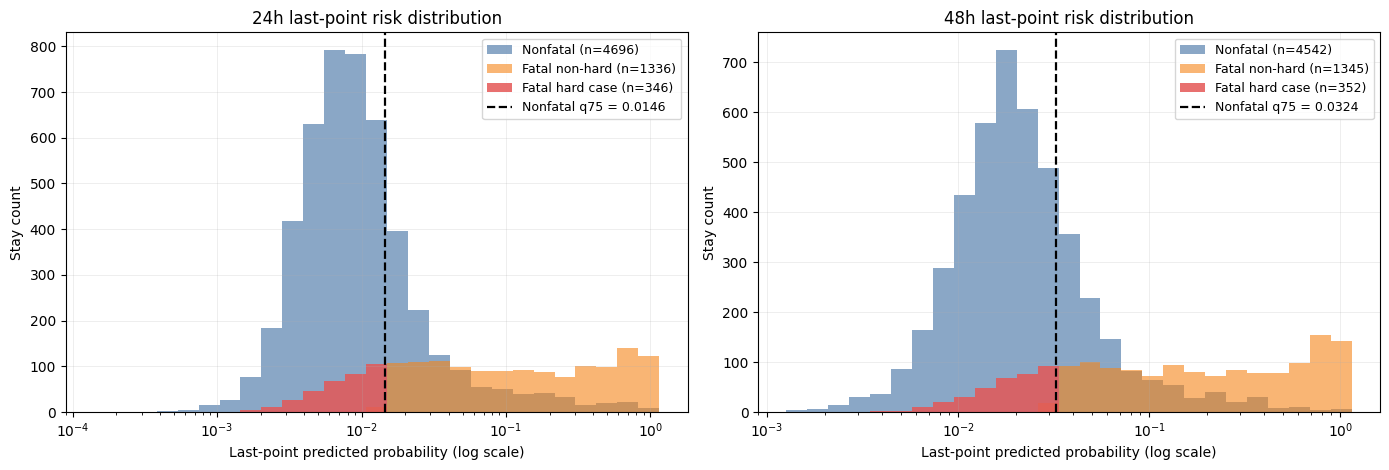

### Distribution Context Table

,horizon_h,group,n,min,median,p75,max
0,24,nonfatal,4696,0.000140,0.008322,0.014598,0.952700
1,24,fatal,1682,0.000824,0.072793,0.344403,0.999672
2,24,fatal_hard,346,0.000824,0.008405,0.011567,0.014576
3,48,nonfatal,4542,0.001262,0.019615,0.032415,0.998548
4,48,fatal,1697,0.002812,0.130298,0.497143,0.999782
5,48,fatal_hard,352,0.002812,0.019619,0.026176,0.032295


In [6]:
selected_horizons = [h for h in [PRIMARY_HORIZON, SECONDARY_HORIZON] if h in logistic_stay["horizon_h"].astype(int).unique().tolist()]
fig, axes = plt.subplots(1, len(selected_horizons), figsize=(7 * len(selected_horizons), 4.8))
if len(selected_horizons) == 1:
    axes = [axes]
for ax, horizon_h in zip(axes, selected_horizons):
    plot_last_point_risk_distribution(logistic_stay, horizon_h=horizon_h, ax=ax)
plt.tight_layout()
finalize_figure(fig)

risk_quantiles = []
for horizon_h in selected_horizons:
    subset = logistic_stay[logistic_stay["horizon_h"].astype(int).eq(int(horizon_h))].copy()
    for label, frame in [
        ("nonfatal", subset[subset["label_value"].eq(0)]),
        ("fatal", subset[subset["label_value"].eq(1)]),
        ("fatal_hard", subset[subset["hard_case_flag"].astype(bool)]),
    ]:
        if frame.empty:
            continue
        risk_quantiles.append(
            {
                "horizon_h": int(horizon_h),
                "group": label,
                "n": int(frame.shape[0]),
                "min": float(frame["predicted_probability"].min()),
                "median": float(frame["predicted_probability"].median()),
                "p75": float(frame["predicted_probability"].quantile(0.75)),
                "max": float(frame["predicted_probability"].max()),
            }
        )

display(Markdown("### Distribution Context Table"))
display(pd.DataFrame(risk_quantiles))
        

## 4. Hospital / Site Breakdown
        

### Hospital-Horizon Table

,hospital_id,horizon_h,fatal_stays,hard_cases,hard_case_rate_among_fatal
0,asic_UK02,8,210,32,0.152381
1,asic_UK02,16,211,27,0.127962
2,asic_UK02,24,212,27,0.127358
3,asic_UK02,48,212,30,0.141509
4,asic_UK02,72,213,32,0.150235
5,asic_UK04,8,105,35,0.333333
6,asic_UK04,16,108,36,0.333333
7,asic_UK04,24,108,37,0.342593
8,asic_UK04,48,111,37,0.333333
9,asic_UK04,72,111,35,0.315315


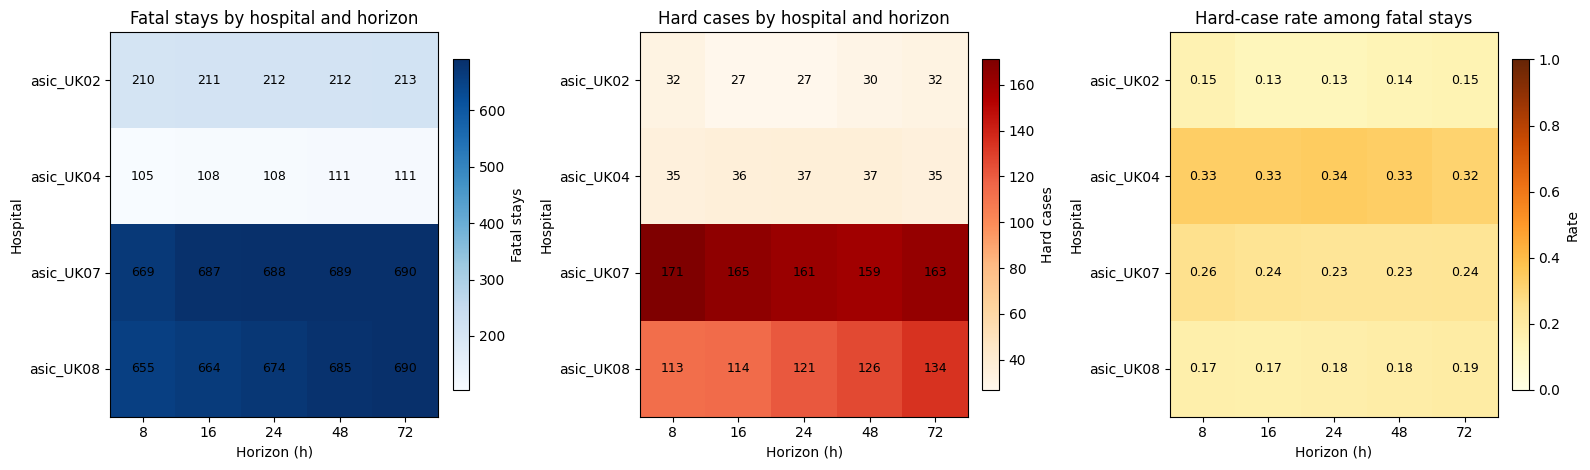

In [7]:
hospital_horizon = (
    logistic_stay.groupby(["hospital_id", "horizon_h"], dropna=False)
    .agg(
        fatal_stays=("label_value", lambda series: int(pd.Series(series).eq(1).sum())),
        hard_cases=("hard_case_flag", lambda series: int(pd.Series(series).astype(bool).sum())),
    )
    .reset_index()
    .sort_values(["hospital_id", "horizon_h"])
    .reset_index(drop=True)
)
hospital_horizon["hard_case_rate_among_fatal"] = hospital_horizon.apply(
    lambda row: float(row["hard_cases"] / row["fatal_stays"]) if row["fatal_stays"] else np.nan,
    axis=1,
)

display(Markdown("### Hospital-Horizon Table"))
display(hospital_horizon)

fatal_table = hospital_horizon.pivot(index="hospital_id", columns="horizon_h", values="fatal_stays").sort_index(axis=1)
hard_table = hospital_horizon.pivot(index="hospital_id", columns="horizon_h", values="hard_cases").sort_index(axis=1)
rate_table = hospital_horizon.pivot(index="hospital_id", columns="horizon_h", values="hard_case_rate_among_fatal").sort_index(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
plot_annotated_heatmap(fatal_table, ax=axes[0], title="Fatal stays by hospital and horizon", cmap="Blues", value_format="{:.0f}", colorbar_label="Fatal stays")
plot_annotated_heatmap(hard_table, ax=axes[1], title="Hard cases by hospital and horizon", cmap="OrRd", value_format="{:.0f}", colorbar_label="Hard cases")
plot_annotated_heatmap(rate_table, ax=axes[2], title="Hard-case rate among fatal stays", cmap="YlOrBr", value_format="{:.2f}", colorbar_label="Rate", vmin=0.0, vmax=1.0)
plt.tight_layout()
finalize_figure(fig)
        

## 5. Example Stay-Level View Of Selected Hard Cases
        

In [8]:
example_columns = [
    "stay_id_global",
    "hospital_id",
    "horizon_h",
    "instance_id",
    "block_index",
    "prediction_time_h",
    "predicted_probability",
    "nonfatal_q75_threshold",
    "hard_case_flag",
]

lowest_hard_cases = (
    logistic_stay[logistic_stay["hard_case_flag"].astype(bool)]
    .sort_values(["predicted_probability", "horizon_h", "hospital_id", "stay_id_global"])
    .loc[:, example_columns]
    .head(10)
    .reset_index(drop=True)
)

near_threshold_nonhard_fatal = (
    logistic_stay[
        logistic_stay["label_value"].eq(1) & ~logistic_stay["hard_case_flag"].astype(bool)
    ]
    .assign(distance_to_threshold=lambda frame: (frame["predicted_probability"] - frame["nonfatal_q75_threshold"]).abs())
    .sort_values(["distance_to_threshold", "horizon_h", "hospital_id", "stay_id_global"])
    .loc[:, [*example_columns, "distance_to_threshold"]]
    .head(10)
    .reset_index(drop=True)
)

display(Markdown("### 10 hard cases with the lowest predicted probability"))
display(lowest_hard_cases)

display(Markdown("### 10 non-hard fatal stays closest to the horizon-specific threshold"))
display(near_threshold_nonhard_fatal)
        

### 10 hard cases with the lowest predicted probability

,stay_id_global,hospital_id,horizon_h,instance_id,block_index,prediction_time_h,predicted_probability,nonfatal_q75_threshold,hard_case_flag
0,asic_UK07_1753,asic_UK07,8,asic_UK07_1753__b26__h8,26,216,0.000150,0.004425,True
1,asic_UK08_5010,asic_UK08,8,asic_UK08_5010__b28__h8,28,232,0.000252,0.004425,True
2,asic_UK08_1989,asic_UK08,8,asic_UK08_1989__b8__h8,8,72,0.000364,0.004425,True
3,asic_UK07_978,asic_UK07,8,asic_UK07_978__b11__h8,11,96,0.000403,0.004425,True
4,asic_UK08_2634,asic_UK08,8,asic_UK08_2634__b9__h8,9,80,0.000420,0.004425,True
5,asic_UK04_437,asic_UK04,8,asic_UK04_437__b29__h8,29,240,0.000433,0.004425,True
6,asic_UK07_1753,asic_UK07,16,asic_UK07_1753__b26__h16,26,216,0.000437,0.009295,True
7,asic_UK07_146,asic_UK07,8,asic_UK07_146__b5__h8,5,48,0.000444,0.004425,True
8,asic_UK08_762,asic_UK08,8,asic_UK08_762__b20__h8,20,168,0.000473,0.004425,True
9,asic_UK08_396,asic_UK08,8,asic_UK08_396__b63__h8,63,512,0.000479,0.004425,True


### 10 non-hard fatal stays closest to the horizon-specific threshold

,stay_id_global,hospital_id,horizon_h,instance_id,block_index,prediction_time_h,predicted_probability,nonfatal_q75_threshold,hard_case_flag,distance_to_threshold
0,asic_UK07_609,asic_UK07,16,asic_UK07_609__b12__h16,12,104,0.009302,0.009295,False,0.000007
1,asic_UK08_2710,asic_UK08,24,asic_UK08_2710__b15__h24,15,128,0.014608,0.014598,False,0.000010
2,asic_UK07_884,asic_UK07,16,asic_UK07_884__b37__h16,37,304,0.009313,0.009295,False,0.000018
3,asic_UK02_248,asic_UK02,8,asic_UK02_248__b33__h8,33,272,0.004444,0.004425,False,0.000019
4,asic_UK07_881,asic_UK07,8,asic_UK07_881__b26__h8,26,216,0.004446,0.004425,False,0.000021
5,asic_UK08_1486,asic_UK08,48,asic_UK08_1486__b23__h48,23,192,0.032443,0.032415,False,0.000027
6,asic_UK07_781,asic_UK07,8,asic_UK07_781__b10__h8,10,88,0.004456,0.004425,False,0.000031
7,asic_UK08_255,asic_UK08,48,asic_UK08_255__b2__h48,2,24,0.032450,0.032415,False,0.000035
8,asic_UK08_4550,asic_UK08,8,asic_UK08_4550__b358__h8,358,2872,0.004462,0.004425,False,0.000037
9,asic_UK07_391,asic_UK07,24,asic_UK07_391__b7__h24,7,64,0.014644,0.014598,False,0.000046


## 6. Cross-Model Agreement View
        

In [9]:
if not agreement_available:
    display(Markdown("_Agreement artifacts were not found at the configured default path, so this section is skipped._"))
else:
    agreement_counts = agreement_summary[
        [
            "horizon_h",
            "n_logistic_hard",
            "n_xgb_recal_hard",
            "n_both_hard",
            "n_logistic_only",
            "n_xgb_recal_only",
            "jaccard_hard_case_overlap",
            "pct_logistic_hard_confirmed_by_xgb",
            "pct_xgb_recal_hard_confirmed_by_logistic",
            "agreement_subgroup_warning",
            "warning_reason",
        ]
    ].sort_values("horizon_h").reset_index(drop=True)

    display(Markdown("### Agreement Summary Table"))
    display(agreement_counts)

    plot_frame = agreement_summary.sort_values("horizon_h").reset_index(drop=True)
    x_positions = np.arange(plot_frame.shape[0])
    bar_width = 0.24

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    axes[0].bar(x_positions - bar_width, plot_frame["n_logistic_hard"], width=bar_width, color="#4c78a8", label="Logistic hard")
    axes[0].bar(x_positions, plot_frame["n_xgb_recal_hard"], width=bar_width, color="#54a24b", label="Recalibrated XGBoost hard")
    axes[0].bar(x_positions + bar_width, plot_frame["n_both_hard"], width=bar_width, color="#e45756", label="Both")
    axes[0].set_title("Hard-case counts by horizon")
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels(plot_frame["horizon_h"].astype(int).astype(str))
    axes[0].set_xlabel("Horizon (h)")
    axes[0].set_ylabel("Fatal stays")
    axes[0].grid(axis="y", alpha=0.25)
    axes[0].legend()

    stacked = plot_frame.set_index("horizon_h")[["n_both_hard", "n_logistic_only", "n_xgb_recal_only"]]
    stacked.columns = ["Both", "Logistic only", "XGBoost only"]
    stacked.plot(kind="bar", stacked=True, ax=axes[1], color=["#e45756", "#4c78a8", "#54a24b"])
    axes[1].set_title("Agreement composition among fatal stays")
    axes[1].set_xlabel("Horizon (h)")
    axes[1].set_ylabel("Fatal stays")
    axes[1].grid(axis="y", alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    finalize_figure(fig)

    agreement_plot = agreement_stay.copy()
    agreement_plot["agreement_category"] = agreement_category(agreement_plot)
    category_counts = (
        agreement_plot.groupby(["horizon_h", "agreement_category"]).size().unstack(fill_value=0)
        .sort_index()
        .reset_index()
    )
    display(Markdown("### Agreement category counts by horizon"))
    display(category_counts)

    positive_values = agreement_plot[["logistic_predicted_probability", "xgb_recal_predicted_probability"]].to_numpy(dtype=float)
    positive_values = positive_values[np.isfinite(positive_values) & (positive_values > 0)]
    lower = max(float(positive_values.min()), 1e-6) if positive_values.size else 1e-6

    fig, ax = plt.subplots(figsize=(6.4, 5.6))
    for category_name, color in {
        "both": "#e45756",
        "logistic_only": "#4c78a8",
        "xgb_only": "#54a24b",
        "neither": "#9d9da1",
    }.items():
        subset = agreement_plot[agreement_plot["agreement_category"].eq(category_name)].copy()
        if subset.empty:
            continue
        ax.scatter(
            np.clip(subset["logistic_predicted_probability"].to_numpy(dtype=float), lower, None),
            np.clip(subset["xgb_recal_predicted_probability"].to_numpy(dtype=float), lower, None),
            s=55,
            alpha=0.85,
            color=color,
            label=f"{category_name.replace('_', ' ').title()} (n={len(subset)})",
        )
    ax.plot([lower, 1.0], [lower, 1.0], linestyle="--", color="black", linewidth=1.0)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Logistic last-point predicted probability")
    ax.set_ylabel("Recalibrated XGBoost last-point predicted probability")
    ax.set_title("Fatal stays: logistic vs recalibrated XGBoost")
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=9)
    plt.tight_layout()
    finalize_figure(fig)
        

_Agreement artifacts were not found at the configured default path, so this section is skipped._

## 7. Short Notebook Conclusion Cell
        

In [10]:
largest_subgroup = logistic_summary.sort_values(["n_hard_cases", "pct_fatal_hard_cases"], ascending=[False, False]).iloc[0]
smallest_subgroup = logistic_summary.sort_values(["n_hard_cases", "pct_fatal_hard_cases"], ascending=[True, True]).iloc[0]
warning_horizons = logistic_summary.loc[logistic_summary["subgroup_size_warning"].astype(bool), "horizon_h"].astype(int).tolist()

hospital_dominance_rows = []
for horizon_h, horizon_df in hospital_horizon.groupby("horizon_h", dropna=False):
    total_hard = int(horizon_df["hard_cases"].sum())
    if total_hard == 0:
        continue
    top_row = horizon_df.sort_values(["hard_cases", "fatal_stays"], ascending=[False, False]).iloc[0]
    hospital_dominance_rows.append(
        {
            "horizon_h": int(horizon_h),
            "hospital_id": str(top_row["hospital_id"]),
            "hard_cases": int(top_row["hard_cases"]),
            "share_of_hard_cases": float(top_row["hard_cases"] / total_hard),
        }
    )
hospital_dominance = pd.DataFrame(hospital_dominance_rows)

summary_lines = [
    f"- Largest hard-case subgroup: {int(largest_subgroup['horizon_h'])}h ({int(largest_subgroup['n_hard_cases'])} stays; {float(largest_subgroup['pct_fatal_hard_cases']):.1%} of fatal stays).",
    f"- Smallest hard-case subgroup: {int(smallest_subgroup['horizon_h'])}h ({int(smallest_subgroup['n_hard_cases'])} stays; {float(smallest_subgroup['pct_fatal_hard_cases']):.1%} of fatal stays).",
    f"- Subgroup-size warnings were triggered for horizons: {', '.join(str(h) for h in warning_horizons)}.",
]

if not hospital_dominance.empty:
    top_dominance = hospital_dominance.sort_values("share_of_hard_cases", ascending=False).iloc[0]
    summary_lines.append(
        f"- Largest within-horizon hospital share of hard cases: {top_dominance['hospital_id']} at {int(top_dominance['horizon_h'])}h ({int(top_dominance['hard_cases'])} cases; {float(top_dominance['share_of_hard_cases']):.1%} of that horizon's hard cases)."
    )
else:
    summary_lines.append("- No hospital-level hard-case counts were available to summarize.")

if agreement_available:
    valid_jaccard = agreement_summary["jaccard_hard_case_overlap"].dropna().astype(float)
    if not valid_jaccard.empty:
        summary_lines.append(
            f"- Cross-model agreement Jaccard ranged from {valid_jaccard.min():.2f} to {valid_jaccard.max():.2f} (median {valid_jaccard.median():.2f})."
        )
    zero_both_horizons = agreement_summary.loc[agreement_summary["n_both_hard"].eq(0), "horizon_h"].astype(int).tolist()
    if zero_both_horizons:
        summary_lines.append(
            f"- Horizons with zero agreed hard cases: {', '.join(str(h) for h in zero_both_horizons)}."
        )
    agreement_warning_horizons = agreement_summary.loc[
        agreement_summary["agreement_subgroup_warning"].astype(bool), "horizon_h"
    ].astype(int).tolist()
    summary_lines.append(
        f"- Agreement warnings were triggered for horizons: {', '.join(str(h) for h in agreement_warning_horizons)}."
    )
else:
    summary_lines.append("- Agreement artifacts were not available, so no cross-model takeaway was computed.")

display(Markdown("### First-pass takeaways\n" + "\n".join(summary_lines)))
        

### First-pass takeaways
- Largest hard-case subgroup: 72h (364 stays; 21.4% of fatal stays).
- Smallest hard-case subgroup: 16h (342 stays; 20.5% of fatal stays).
- Subgroup-size warnings were triggered for horizons: .
- Largest within-horizon hospital share of hard cases: asic_UK07 at 8h (171 cases; 48.7% of that horizon's hard cases).
- Agreement artifacts were not available, so no cross-model takeaway was computed.